## Bloque 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Bloque 1 — Carga

In [2]:
from pathlib import Path

# Cambiar segun el formato de los archivos fuente: 'csv' o 'xlsx'
FORMAT = 'csv'

# Solo se ingieren los archivos del sensor Fronius (no los del resto de entidades)
SOURCE_GLOB = 'etfroniussensorcard_*'

COL_MAP = {
    'Fecha y Hora': 'time_index_colombia',
    'ID Entidad':   'entity_id',
}

if FORMAT == 'csv':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.csv'))
    def load(f):
        return pd.read_csv(f, sep=',', low_memory=False)

elif FORMAT == 'xlsx':
    files = sorted(Path('.').glob(f'{SOURCE_GLOB}.xlsx'))
    def load(f):
        return pd.read_excel(f)

print(f'{len(files)} archivos encontrados:')
for f in files:
    print(' ', f.name)

partes = []
for f in files:
    chunk = load(f)
    chunk.rename(columns=COL_MAP, inplace=True)
    partes.append(chunk)

df = pd.concat(partes, join='outer', ignore_index=True)

# Avisar si algun archivo tiene columnas distintas al resto
col_sets = [set(p.columns) for p in partes]
extra = set.union(*col_sets) - set.intersection(*col_sets)
if extra:
    print('Columnas inconsistentes entre archivos:', extra)

print(f'Shape combinado: {df.shape}')
df.head()

1 archivos encontrados:
  etfroniussensorcard_2026-06-06_23-25-47.csv
Shape combinado: (58949, 12)


,entity_id,Tipo Entidad,time_index_colombia,fiware_servicepath,__original_ngsi_entity__,instanceid,refplant,ipaddress,sensorcardid,paneltemperature,ambienttemperature,solarirradiation
0,fronius_plant_52kWpsensor_card1,FroniusSensorCard,2026-01-30 22:52:02,/,NaN,urn:ngsi-ld:62710d7c-0115-4775-a9f5-5c7a8416cd96,fronius_plant_52kWp,10.60.32.30,1,20,21,0
1,fronius_plant_52kWpsensor_card1,FroniusSensorCard,2026-01-31 00:12:55,/,NaN,urn:ngsi-ld:6c4487f4-7bb8-41b5-b37e-97bab90845ea,fronius_plant_52kWp,10.60.32.30,1,21,21,0
2,fronius_plant_52kWpsensor_card1,FroniusSensorCard,2026-01-31 04:17:38,/,NaN,urn:ngsi-ld:336b8e75-2b57-42f6-869e-1b97f4513886,fronius_plant_52kWp,10.60.32.30,1,19,19,0
3,fronius_plant_52kWpsensor_card1,FroniusSensorCard,2026-01-31 06:35:19,/,NaN,urn:ngsi-ld:f2b33c48-9f93-4277-b4ed-1708ab1c09ea,fronius_plant_52kWp,10.60.32.30,1,19,20,0
4,fronius_plant_52kWpsensor_card1,FroniusSensorCard,2026-01-31 06:36:50,/,NaN,urn:ngsi-ld:e119b973-02ee-4043-9924-d87b5bbc1b4e,fronius_plant_52kWp,10.60.32.30,1,19,20,1


## Bloque 2 — Conversión de tipos y selección de columnas

In [3]:
COLS = ['time_index_colombia', 'entity_id',
        'paneltemperature', 'ambienttemperature', 'solarirradiation']
df = df[COLS].copy()

df['time_index_colombia'] = pd.to_datetime(df['time_index_colombia'], utc=False, format='%Y-%m-%d %H:%M:%S')
df['entity_id'] = df['entity_id'].astype('category')

num_cols = ['paneltemperature', 'ambienttemperature', 'solarirradiation']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

time_index_colombia    datetime64[ns]
entity_id                    category
paneltemperature                int64
ambienttemperature              int64
solarirradiation                int64
dtype: object

## Bloque 3 — Descripción estadística

### 3.1 Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58949 entries, 0 to 58948
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   time_index_colombia  58949 non-null  datetime64[ns]
 1   entity_id            58949 non-null  category      
 2   paneltemperature     58949 non-null  int64         
 3   ambienttemperature   58949 non-null  int64         
 4   solarirradiation     58949 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(3)
memory usage: 1.9 MB


In [5]:
df.describe(include='all')

,time_index_colombia,entity_id,paneltemperature,ambienttemperature,solarirradiation
count,58949,58949,58949.000000,58949.000000,58949.000000
unique,NaN,1,NaN,NaN,NaN
top,NaN,fronius_plant_52kWpsensor_card1,NaN,NaN,NaN
freq,NaN,58949,NaN,NaN,NaN
mean,2026-04-05 06:33:34.547388416,NaN,32.275832,27.922289,379.060306
min,2026-01-30 22:52:02,NaN,16.000000,16.000000,0.000000
25%,2026-03-03 06:54:32,NaN,26.000000,24.000000,106.000000
50%,2026-04-09 15:37:40,NaN,32.000000,28.000000,288.000000
75%,2026-05-08 09:35:33,NaN,38.000000,32.000000,617.000000
max,2026-06-05 18:06:50,NaN,52.000000,41.000000,1361.000000


### 3.2 — Distribución temporal y por entidad

**Celda A — Registros por día**

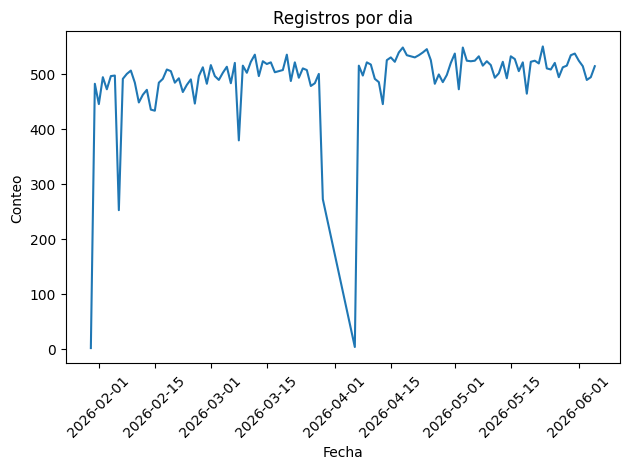

In [6]:
by_day = df.groupby(df['time_index_colombia'].dt.date).size()
fig, ax = plt.subplots()
ax.plot(by_day.index, by_day.values)
ax.set_xlabel('Fecha')
ax.set_ylabel('Conteo')
ax.set_title('Registros por dia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Celda B — Registros por hora del día**

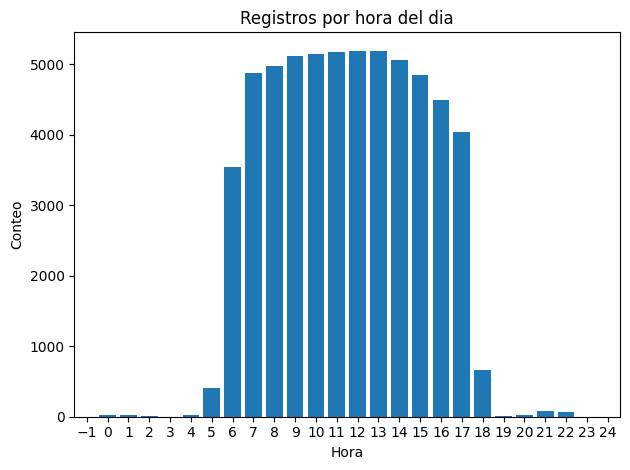

In [7]:
by_hour = df.groupby(df['time_index_colombia'].dt.hour).size()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values)
ax.set_xlabel('Hora')
ax.set_ylabel('Conteo')
ax.set_title('Registros por hora del dia')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

**Celda C — Registros por entity_id**

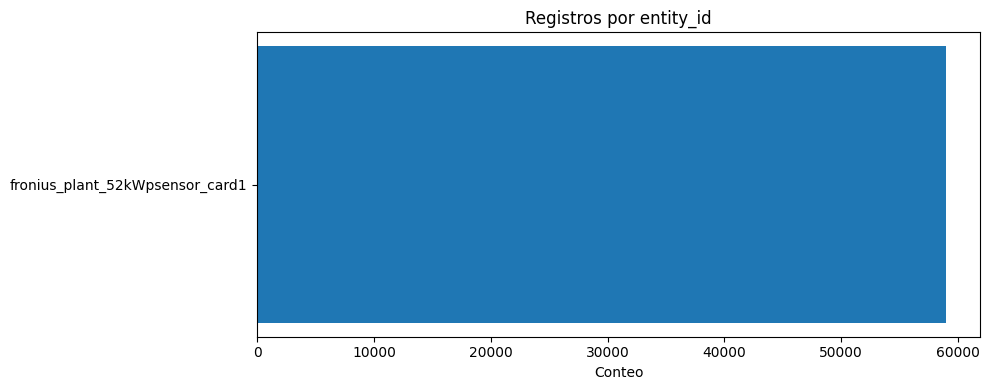

In [8]:
by_entity = df['entity_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, max(4, len(by_entity) * 0.3)))
ax.barh(by_entity.index.astype(str), by_entity.values)
ax.set_xlabel('Conteo')
ax.set_title('Registros por entity_id')
plt.tight_layout()
plt.show()

### 3.3 — Distribuciones de variables numéricas

**paneltemperature — histograma**

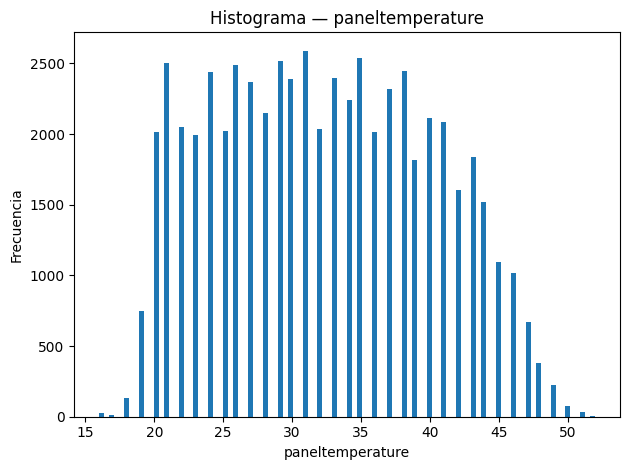

In [9]:
fig, ax = plt.subplots()
ax.hist(df['paneltemperature'].dropna(), bins=100)
ax.set_xlabel('paneltemperature')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — paneltemperature')
plt.tight_layout()
plt.show()

**paneltemperature — boxplot**

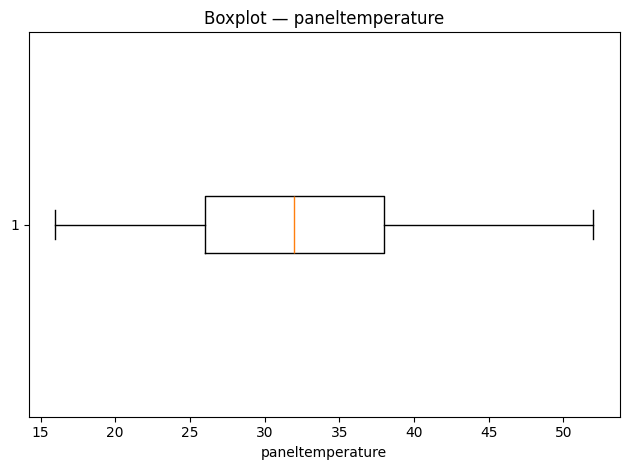

In [10]:
fig, ax = plt.subplots()
ax.boxplot(df['paneltemperature'].dropna(), vert=False)
ax.set_xlabel('paneltemperature')
ax.set_title('Boxplot — paneltemperature')
plt.tight_layout()
plt.show()

**ambienttemperature — histograma**

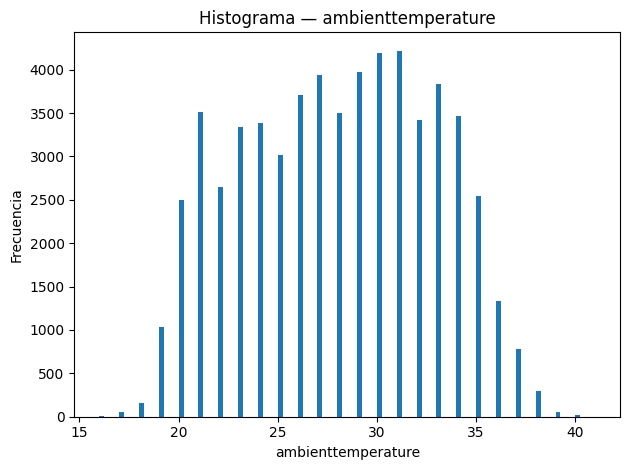

In [11]:
fig, ax = plt.subplots()
ax.hist(df['ambienttemperature'].dropna(), bins=100)
ax.set_xlabel('ambienttemperature')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — ambienttemperature')
plt.tight_layout()
plt.show()

**ambienttemperature — boxplot**

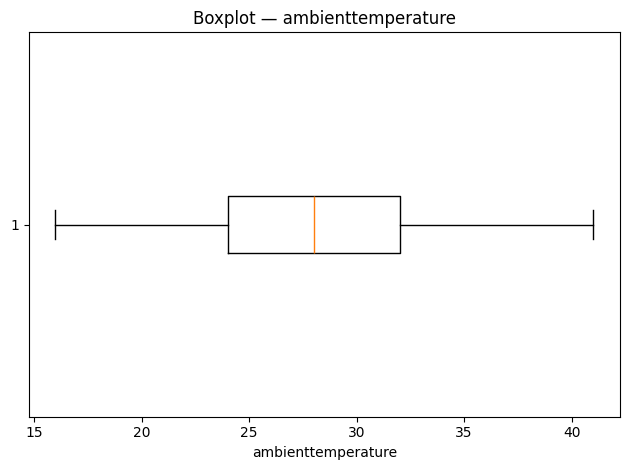

In [12]:
fig, ax = plt.subplots()
ax.boxplot(df['ambienttemperature'].dropna(), vert=False)
ax.set_xlabel('ambienttemperature')
ax.set_title('Boxplot — ambienttemperature')
plt.tight_layout()
plt.show()

**solarirradiation — histograma**

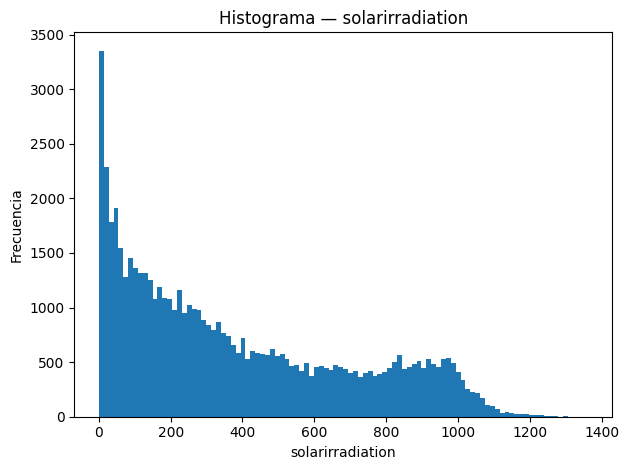

In [13]:
fig, ax = plt.subplots()
ax.hist(df['solarirradiation'].dropna(), bins=100)
ax.set_xlabel('solarirradiation')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma — solarirradiation')
plt.tight_layout()
plt.show()

**solarirradiation — boxplot**

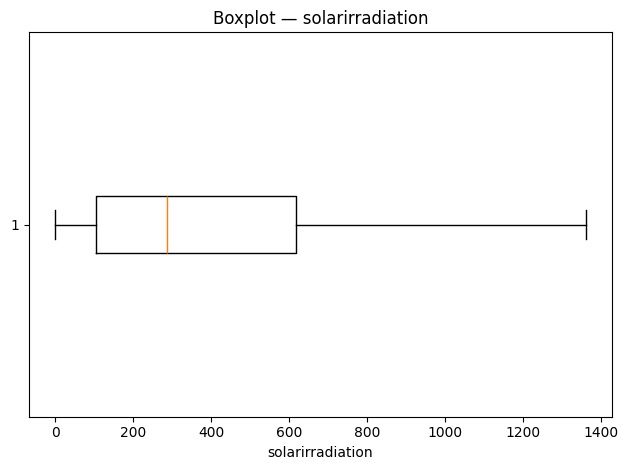

In [14]:
fig, ax = plt.subplots()
ax.boxplot(df['solarirradiation'].dropna(), vert=False)
ax.set_xlabel('solarirradiation')
ax.set_title('Boxplot — solarirradiation')
plt.tight_layout()
plt.show()

## Bloque 4 — Limpieza de atípicos

### 4.1 — Conversión a numéricos

In [15]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 4.2 — Validación de rangos físicos

In [16]:
print('NaNs antes:')
print(df[num_cols].isna().sum())

RANGES = {
    'paneltemperature':    (0, 100),    # C — temperatura de panel
    'ambienttemperature':  (-10, 60),   # C — temperatura ambiente
    'solarirradiation':    (0, 1500),   # W/m2 — irradiancia solar
}

for col, (lo, hi) in RANGES.items():
    df[col] = df[col].where(df[col].between(lo, hi))

print('NaNs despues:')
print(df[num_cols].isna().sum())

NaNs antes:
paneltemperature      0
ambienttemperature    0
solarirradiation      0
dtype: int64
NaNs despues:
paneltemperature      0
ambienttemperature    0
solarirradiation      0
dtype: int64


### 4.3 — Eliminación de filas sin información esencial

In [17]:
before = len(df)
df.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df)}  — shape resultante: {df.shape}')

Filas eliminadas: 0  — shape resultante: (58949, 5)


## Bloque 5 — Resample configurable

In [18]:
FREQ = '60min'

df_resampled = (
    df.set_index('time_index_colombia')
    .groupby('entity_id', observed=True)
    .resample(FREQ)
    .agg({
        'paneltemperature':   'mean',
        'ambienttemperature': 'mean',
        'solarirradiation':   'mean',
    })
    .reset_index()
)

print(df_resampled.shape)

(3021, 5)


In [19]:
before = len(df_resampled)
df_resampled.dropna(inplace=True)
print(f'Filas eliminadas: {before - len(df_resampled)}  — shape resultante: {df_resampled.shape}')

Filas eliminadas: 1142  — shape resultante: (1879, 5)


## Bloque 6 — Exportación

In [20]:
csv_path     = 'clean_etfroniussensorcard.csv'
parquet_path = 'clean_etfroniussensorcard.parquet'

df_resampled.to_csv(csv_path, index=False)
df_resampled.to_parquet(parquet_path, engine='pyarrow', index=False)

print(f'CSV guardado en:     {csv_path}  — shape: {df_resampled.shape}')
print(f'Parquet guardado en: {parquet_path}  — shape: {df_resampled.shape}')

CSV guardado en:     clean_etfroniussensorcard.csv  — shape: (1879, 5)
Parquet guardado en: clean_etfroniussensorcard.parquet  — shape: (1879, 5)
